# ViT(Vision Transformer)

In [2]:
import sys
!{sys.executable} -m pip install -U transformers datasets accelerate huggingface_hub evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets

def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)

    for idx, label in enumerate(dataset.targets):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


train_dataset = datasets.FashionMNIST(root="./datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="./datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

print(classes)
print(class_to_idx)

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=classes, max_len=1000
)

subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=classes, max_len=100
)

print(f"Training Data Size : {len(subset_train_dataset)}")
print(f"Testing Data Size : {len(subset_test_dataset)}")
print(train_dataset[0])


100%|██████████| 26.4M/26.4M [00:03<00:00, 6.68MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 176kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.12MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.52MB/s]


['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
Training Data Size : 10000
Testing Data Size : 1000
(<PIL.Image.Image image mode=L size=28x28 at 0x7FAE0DA96D50>, 9)


- FashionMNIST 데이터세트에 포함된 클래스는 cLasses 속성을 통해 확인
- 클래스 ID와 클래스가 매핑된 값을 확인하려면 class_to_idx 속성을 확인
---
- 데이터세트를 불러오고 구조를 확인했다면 Subset_sampler 함수를 선언해 서브 샘플링을 수행
- Subset_sampler 함수는 데이터세트 (dataset), 클래스 목록 (classes), 클래스별 최대 샘플링 개수 (max_Len)를 전달
---
- 기본값이 있는 딕셔너리(defaultdict)클래스를 활용해 클래스마다 1,000개의 데이터 색인값을 가져옴
- 색인 값을 1차원 리스트로 풀어 서브셋(Subset)클래스에 전달하면 해당 색인 값에 해당하는 데이
터세트를 추출 가능
---
- 서브 샘플링을 수행했다면 서브셋 데이터세트와 개별 데이터를 확인
- 서브셋 데이터세트는 각 10000개와 1000개가 반환되며, 개별 데이터는 PIL이미지와 클래스 번호를 담고 있음

In [ ]:
import torch
from torchvision import transforms
from transformers import AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x,x,x],0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

print(f"size : {image_processor.size}")
print(f"mean : {image_processor.image_mean}")
print(f"std : {image_processor.image_std}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


size : {'height': 224, 'width': 224}
mean : [0.5, 0.5, 0.5]
std : [0.5, 0.5, 0.5]


###이미지 프로세서 클래스 (AutoImageProcessor)
- 사전 학습된 ViT 모델을 활용해 전처리를 진행
- 이미지 프로세서 클래스는 자르기(Crop)나 크기 조정(resize)등의 전처리를 수행 가능

---
- 사용되는 9oogLe/vit-base-patch16-224-in21K 모델 : ImageNet-21K* 데이터세트를 사용
- 224X 224 이미지 크기와 16개의 이미지 패치를 기반으로 학습
---
- 모델 학습 시 PIL.Image 형식이 아닌 Tensor 형식을 사용하므로 변환 모듈을 통해 이미지를 변환
- 학습에 사용하려는 이미지를 ViT 모델과 맞추기 위해 크기 조정 (transforms.Resize)을 진행
- 사용자 정의 함수 클래스(transforms.Lambda) 단일 채널을 복제해 다중 채널 이미지로 변환
- 이후 정규화 (transforms.Normal.ize) 적용
---
- 학습을 적용하기 위해 전처리 과정이 모두 적용됐지만, ViT 모델은 Tensor 형식의 데이터를 사용하는 것이 아닌 딕셔너리 형식의 데이터를 입력으로 받음
---
- ViT 모델의 입력은 {"pixeL_values": pixeL_values, "Labels": Labels}의 형태를 입력으로 사용
- 그러므로 데이터로더에 집합 함수 (CoLlate_fn) 를 적용해 미니 배치의 샘플 목록을 병합
- 이 함수로 VIT 모델 구조에 맞는 형태로 변환해 데이터로더에 적용

In [ ]:
from torch.utils.data import DataLoader

def collator(data, transform):
  images, labels = zip(*data)
  pixel_values = torch.stack([transform(image) for image in images])
  labels = torch.tensor([label for label in labels])
  return {"pixel_values":pixel_values, "labels": labels}

train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn= lambda x: collator(x, transform),
    drop_last=True
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last = True
)

batch = next(iter(train_dataloader))
for key, value in batch.items():
  print(f"{key} : {value.shape}")

pixel_values : torch.Size([32, 3, 224, 224])
labels : torch.Size([32])


- 데이터로더에 집합 함수 (collate_fn)를 적용하기 위해 사용자 정의 함수(coLLator) 생성
- 집합 함수의 입력값은 데이터로더에서 불러온 배치가 됨
- 현재 예제는 ViT 모델에 맞는 입력 구조 변환을 수행
---
- 그러므로 CoLlator 함수에 transform 변수를 함께 전달해 이미지를 변환하고 {"pixel_values": pixel_values, "labels": Labels} 구조로 값을 반환
  - pixel_values : ( 배치 크기 , 채널 수 , 이미지 높이 , 이미지 너비 ) 로 구성되며 Labels 는 클래스 색인 값을 반환
---
- train_dataloader의 첫 번째 값을 확인해 보면 딕셔너리 형식으로 데이터를 반환하고 배치 크기와 동일한 구조로 데이터가 생성된 것 확인 가능

In [ ]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
    num_labels=len(classes),
    id2label={idx: label for label, idx in class_to_idx.items()},
    label2id=class_to_idx,
    ignore_mismatched_sizes=True
)

print(model.classifier)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Linear(in_features=768, out_features=10, bias=True)


In [ ]:
print(model.vit.embeddings)

batch=next(iter(train_dataloader))
print("image shape : ", batch["pixel_values"].shape)
print("patch embeddings shape : ",
      model.vit.embeddings.patch_embeddings(batch["pixel_values"]).shape
)
print("[CLS] + patch embeddings shape : ",
      model.vit.embeddings(batch["pixel_values"]).shape
)

ViTEmbeddings(
  (patch_embeddings): ViTPatchEmbeddings(
    (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  )
  (dropout): Dropout(p=0.0, inplace=False)
)
image shape :  torch.Size([32, 3, 224, 224])
patch embeddings shape :  torch.Size([32, 196, 768])
[CLS] + patch embeddings shape :  torch.Size([32, 197, 768])


In [ ]:
!pip show transformers

Name: transformers
Version: 4.51.3
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: peft, sentence-transformers


In [ ]:
import transformers
print(transformers.__version__)
print(transformers.__file__)


4.51.3
/usr/local/lib/python3.11/dist-packages/transformers/__init__.py


In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir = "../models/ViT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7
)

###학습 매개변수 클래스(TrainingArgunents)
- 모델 학습에 필요한 다양한 인자들을 저장하고 관리 가능
- 하이퍼파라미터 관리, 모델 평가, 분산 학습, 허깅 페이스 허브 연동, 로그 추적 등의 기능을 제공
- 80 여 개의 매개변수를 통해 다양한 기능을 설정 가능
---
- 하이퍼파라미터 설정이 완료됐다면 모델의 성능을 평가하기 위한 성능 평가 지표 방법을 설정
- 성능 평가 방법은 매크로 평균 F1 점수 (Macro Average F1-Score)를 사용
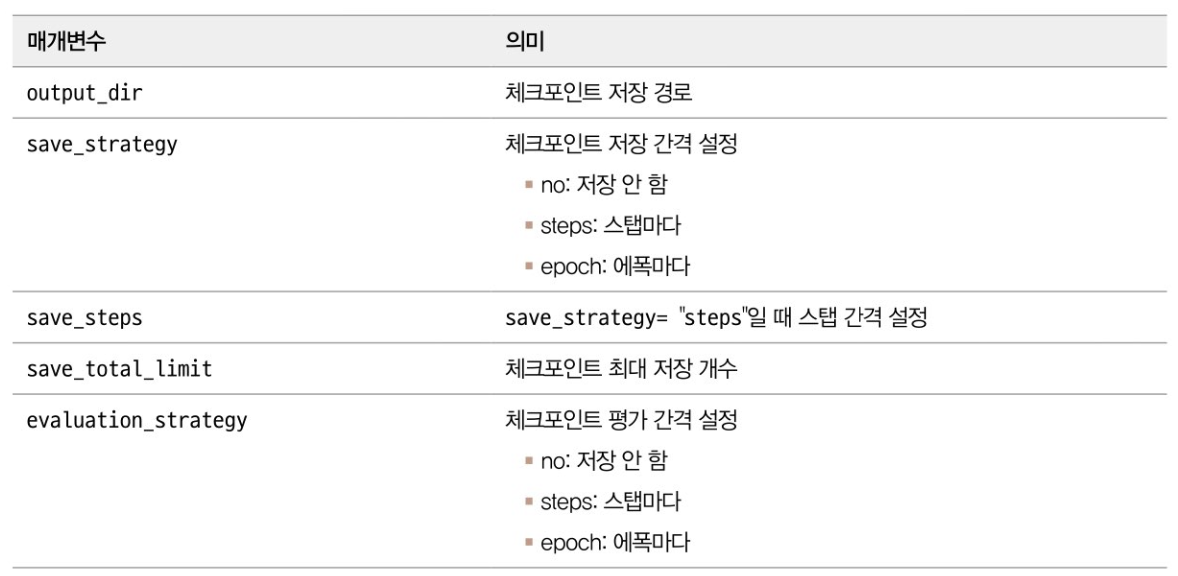
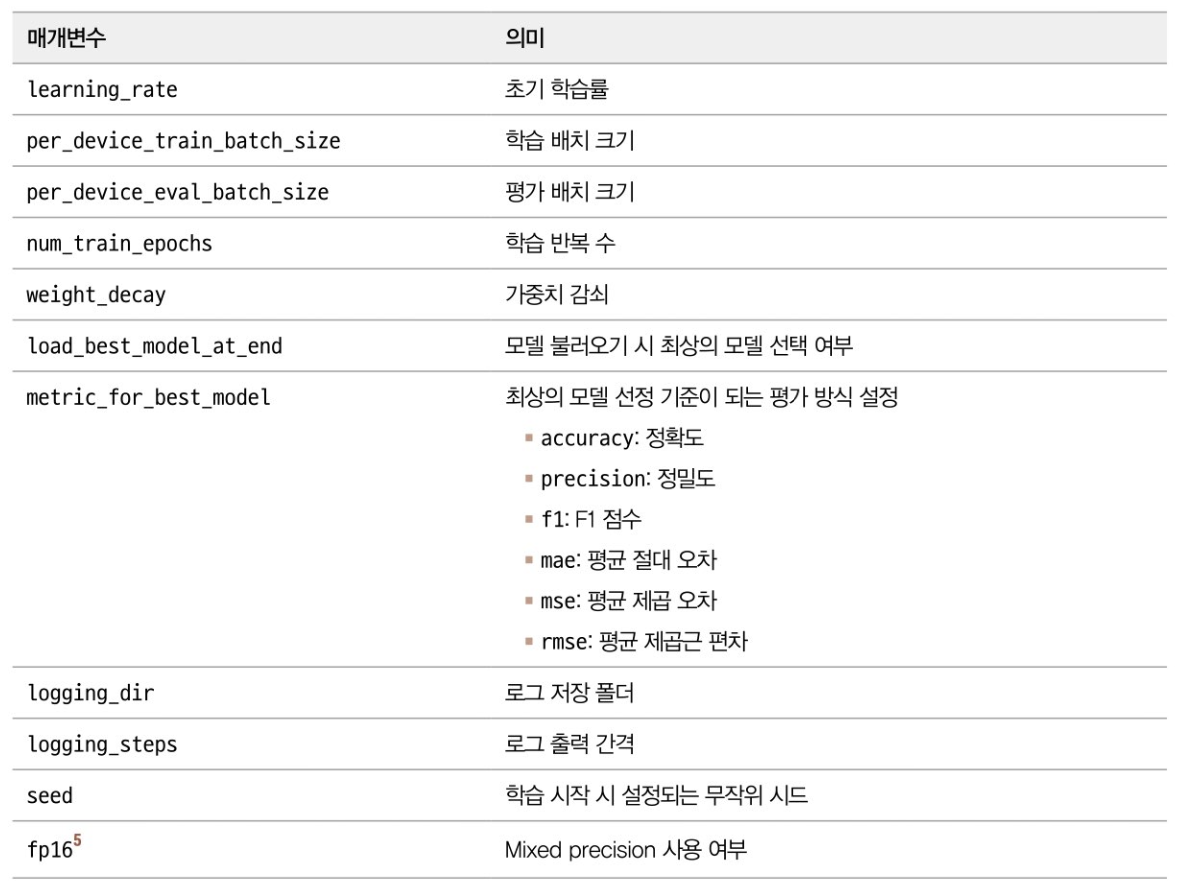

In [ ]:
import evaluate
import numpy as np

def compute_metrics(eval_pred):
  metric = evaluate.load("f1")
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis=1)
  macro_f1= metric.compute(
      predictions = predictions, references=labels, average="macro"
  )
  return macro_f1

- 성능 평가 지표도 허깅 페이스의 평가 라이브러리로 메트릭을 쉽게 불러올 수 있음
- 메트릭 불러오기 함수(Load):  정확도(accuracy), 정밀도(precision), Fl 점수(F1) 등 다양한 평가 지표를 제공
- 이 함수수를 통해 F1 점수 방식을 불러옴
---
- 'compute_netrics 함수에 전달되는 eval_pred 인수는 모델이 예측한 결곳값을 전달받음
- 모든 클래스에 대한 예측값이 포함돼 있으므로, 가장 화률이 높은 값을 선택해 predictions 변수에 저장
---
- 예측 데이터를 정제했다면 예측값(predictions)과 실젯값(Labels)을 메트릭 연산 (metric.compute)메서드에 전달


### ViT 모델 학습

In [5]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from transformers import TrainingArguments, Trainer


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


def model_init(classes, class_to_idx):
    model = ViTForImageClassification.from_pretrained(
        pretrained_model_name_or_path="google/vit-base-patch16-224-in21k",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
    )
    return model


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir="../models/ViT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)
trainer.train()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
<ipython-input-5-a69bbf72d382>:107: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1
1,0.699100,0.630794,0.884339
2,0.476100,0.472204,0.910724
3,0.415600,0.426174,0.920101


TrainOutput(global_step=1875, training_loss=0.6954337748209636, metrics={'train_runtime': 1131.6584, 'train_samples_per_second': 26.51, 'train_steps_per_second': 1.657, 'total_flos': 2.32492637712384e+18, 'train_loss': 0.6954337748209636, 'epoch': 3.0})

PredictionOutput(predictions=array([[ 3.0775366 , -0.6433051 , -0.32252303, ..., -0.5788174 ,
        -0.3491995 , -0.6125769 ],
       [ 2.0966876 , -0.69279975, -0.2729538 , ..., -0.81276375,
        -0.81742316, -0.96525645],
       [ 2.996763  , -0.6120841 , -0.16838211, ..., -0.5238662 ,
        -0.3861029 , -0.6150923 ],
       ...,
       [-0.57482916, -0.6035844 , -0.55603886, ...,  0.6051455 ,
         0.35235333,  3.0057876 ],
       [-0.55968595, -0.38897717, -0.3123542 , ...,  0.15310116,
        -0.3018578 ,  3.4020057 ],
       [-0.5337557 , -0.32446647, -0.2999428 , ..., -0.27108115,
        -0.15024519,  3.4197118 ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

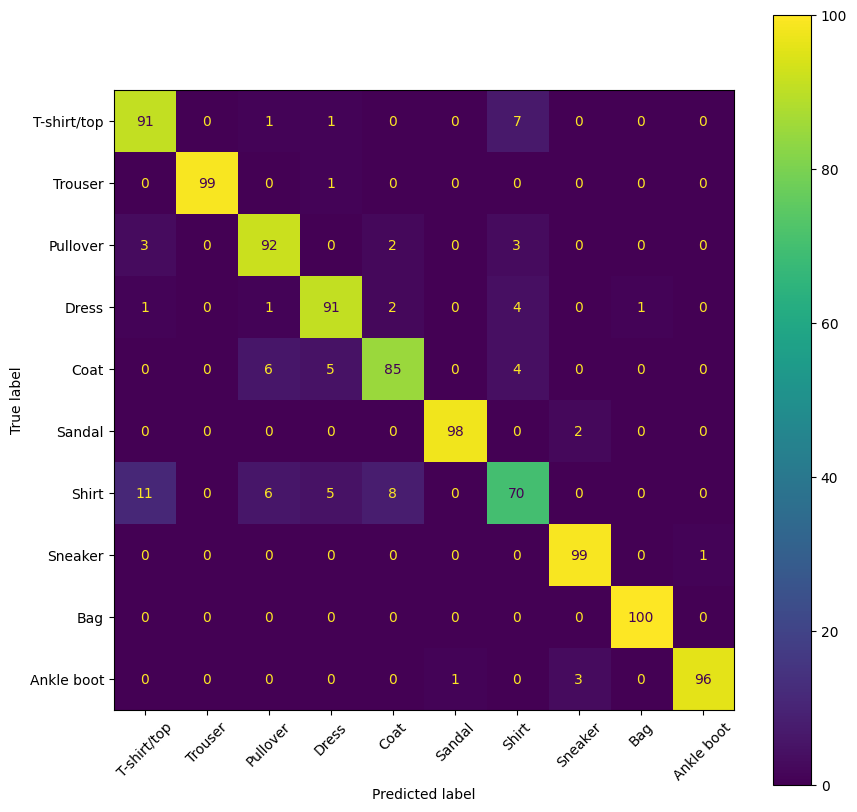

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()

# Swin Transformer

In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

In [ ]:
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

/usr/local/lib/python3.11/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


In [ ]:
import torch
from torchvision import transforms
from transformers import AutoImageProcessor


image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="google/vit-base-patch16-224-in21k"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [ ]:
from torch.utils.data import DataLoader


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)

### 사전 학습된 스윈 트랜스포머 모델

- microsoft/Swin-tiny-patch4-window7-224 모델
  - ImageNet-1k 데이터세트를 사용해 224X 224의 이미지 크기
  - 4X4 의 이미지 패치
  - 7X7 의 로컬 윈도로 학습

In [ ]:
from transformers import SwinForImageClassification


model = SwinForImageClassification.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
    num_labels=len(train_dataset.classes),
    id2label={idx: label for label, idx in train_dataset.class_to_idx.items()},
    label2id=train_dataset.class_to_idx,
    ignore_mismatched_sizes=True
)

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│  └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                if sssub_name == "projection":
                    print("│  │  └", sssub_name, sssub_module)
                else:
                    print("│  │  └", sssub_name)

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


swin
└ embeddings
│  └ patch_embeddings
│  │  └ projection Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
│  └ norm
│  └ dropout
└ encoder
│  └ layers
│  │  └ 0
│  │  └ 1
│  │  └ 2
│  │  └ 3
└ layernorm
└ pooler
classifier


- 패치 파티션과 선형 임베딩은 model.swin.embeddings.patch_embeddings에서 수행
- Patch_embeddings 에서 수행되는 합성곱 계층은 4X4 커널 크기 , 4간격으로 적용

### 패치 임베딩 모듈

In [ ]:
batch = next(iter(train_dataloader))
print("이미지 차원 :", batch["pixel_values"].shape)

patch_emb_output, shape = model.swin.embeddings.patch_embeddings(batch["pixel_values"])
print("모듈:", model.swin.embeddings.patch_embeddings)
print("패치 임베딩 차원 :", patch_emb_output.shape)

이미지 차원 : torch.Size([32, 3, 224, 224])
모듈: SwinPatchEmbeddings(
  (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
)
패치 임베딩 차원 : torch.Size([32, 3136, 96])


### 스윈 트랜스포머 블록

In [ ]:
for main_name, main_module in model.swin.encoder.layers[0].named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("│ └", ssub_name)

blocks
└ 0
│ └ layernorm_before
│ └ attention
│ └ drop_path
│ └ layernorm_after
│ └ intermediate
│ └ output
└ 1
│ └ layernorm_before
│ └ attention
│ └ drop_path
│ └ layernorm_after
│ └ intermediate
│ └ output
downsample
└ reduction
└ norm


### SwinLayer 구조

In [ ]:
print(model.swin.encoder.layers[0].blocks[0])

SwinLayer(
  (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (attention): SwinAttention(
    (self): SwinSelfAttention(
      (query): Linear(in_features=96, out_features=96, bias=True)
      (key): Linear(in_features=96, out_features=96, bias=True)
      (value): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (output): SwinSelfOutput(
      (dense): Linear(in_features=96, out_features=96, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (drop_path): Identity()
  (layernorm_after): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (intermediate): SwinIntermediate(
    (dense): Linear(in_features=96, out_features=384, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): SwinOutput(
    (dense): Linear(in_features=384, out_features=96, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
)


- layernorm_before : 첫 번째 계층 정규화
- attention : W-MSA(SW-MSA)
- layernorm_after : 두번째 계층 정규화
- intermediate 와 output : MLP 를 의미
- MLP 계층을 살펴보면 두 개의 연속된 선형 변환 계층과 GELU(Gaussian Error Linear Unit) 활성
화 함수로 구성
- GELU : ReLU 와 유사한 형태를 가지며. 가우시안 분포에 대한 누적 분포 함수
  - 입력값이 0
  - 주변에서 부드럽게 변화하는 특징
- 스윈 트랜스포머 : 두 개의 연속된 선형 변환과 GELU 함수를 통해 입력 특징맵을 더 깊은 차원으로 매핑하고, ReLU를 사용했을 때보다 더 안정적으로 학습

### W-MSA, SW-MSA 모듈

In [ ]:
print("패치 임베딩 차원 :", patch_emb_output.shape)

W_MSA = model.swin.encoder.layers[0].blocks[0]
SW_MSA = model.swin.encoder.layers[0].blocks[1]

W_MSA_output = W_MSA(patch_emb_output, W_MSA.input_resolution)[0]
SW_MSA_output = SW_MSA(W_MSA_output, SW_MSA.input_resolution)[0]

print("W-MSA 결과 차원 :", W_MSA_output.shape)
print("SW-MSA 결과 차원 :", SW_MSA_output.shape)

패치 임베딩 차원 : torch.Size([32, 3136, 96])
W-MSA 결과 차원 : torch.Size([32, 3136, 96])
SW-MSA 결과 차원 : torch.Size([32, 3136, 96])


### 패치 병합

In [ ]:
patch_merge = model.swin.encoder.layers[0].downsample
print("patch_merge 모듈 :", patch_merge)

output = patch_merge(SW_MSA_output, patch_merge.input_resolution)
print("patch_merge 결과 차원 :", output.shape)

patch_merge 모듈 : SwinPatchMerging(
  (reduction): Linear(in_features=384, out_features=192, bias=False)
  (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
)
patch_merge 결과 차원 : torch.Size([32, 784, 192])


### 스윈 트랜스포머 모델 학습

In [2]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import SwinForImageClassification
from transformers import TrainingArguments, Trainer


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


def model_init(classes, class_to_idx):
    model = SwinForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
        ignore_mismatched_sizes=True
    )
    return model


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/swin-tiny-patch4-window7-224"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["height"],
                image_processor.size["width"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir="../models/Swin-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)
trainer.train()

/usr/local/lib/python3.11/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor

Epoch,Training Loss,Validation Loss,F1
1,0.342100,0.303391,0.890009
2,0.243200,0.248352,0.911482
3,0.213100,0.231063,0.917060


TrainOutput(global_step=1875, training_loss=0.3615388682047526, metrics={'train_runtime': 459.4737, 'train_samples_per_second': 65.292, 'train_steps_per_second': 4.081, 'total_flos': 7.4584635826176e+17, 'train_loss': 0.3615388682047526, 'epoch': 3.0})

PredictionOutput(predictions=array([[ 8.306925  , -2.7653613 ,  0.06759799, ..., -2.184331  ,
        -1.6592457 , -2.1177375 ],
       [ 4.9315343 ,  0.27095455,  1.0432217 , ..., -1.8819221 ,
        -0.9894788 , -3.010298  ],
       [ 7.6776085 , -3.1100485 , -0.5041284 , ..., -1.3948869 ,
         0.29817408, -1.654775  ],
       ...,
       [-1.1375738 , -3.0660374 , -2.295081  , ...,  1.1240982 ,
         1.1817374 ,  4.3918843 ],
       [-0.45994815, -3.1706123 , -1.8085834 , ...,  1.434061  ,
        -2.8013618 ,  9.164463  ],
       [-1.6835977 , -1.895191  , -1.68697   , ..., -1.1948934 ,
        -1.6297514 ,  8.028472  ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

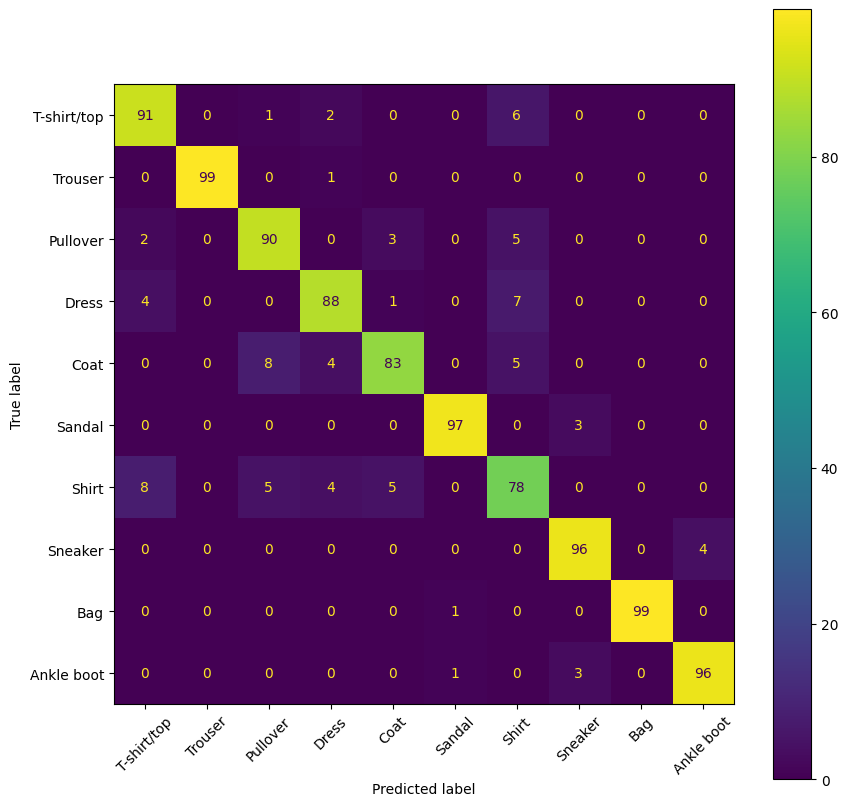

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()

# CvT

In [ ]:
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

/usr/local/lib/python3.11/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


### CvT 모델 이미지 데이터 전처리

In [ ]:
import torch
from torchvision import transforms
from transformers import AutoImageProcessor


image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/cvt-21"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["shortest_edge"],
                image_processor.size["shortest_edge"]
            )
        ),
        transforms.Lambda(lambda x: torch.cat([x, x, x], 0)),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

- CvT 모델: 이미지 크기를 조절할 때 Shortest_edge 키를 사용해 전처리를 진행
- shortest_edge : 이미지의 너비나 높이 중 더 작은 값을 의미
- microsoft/cvt-21 모델은 모든 입력 이미지의 크기를 가장 짧은 이미지 길이로 정규화해 사용하므로 높이나 너비에 대한 키 대신 shortest_edge 를 사용

### 사전 학습된 CvT 모델

In [ ]:
from torch.utils.data import DataLoader


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


train_dataloader = DataLoader(
    subset_train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)
valid_dataloader = DataLoader(
    subset_test_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: collator(x, transform),
    drop_last=True
)

In [ ]:
from transformers import CvtForImageClassification


model = CvtForImageClassification.from_pretrained(
    pretrained_model_name_or_path="microsoft/cvt-21",
    num_labels=len(train_dataset.classes),
    id2label={idx: label for label, idx in train_dataset.class_to_idx.items()},
    label2id=train_dataset.class_to_idx,
    ignore_mismatched_sizes=True
)

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("└", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("   └", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("     └", sssub_name)

config.json:   0%|          | 0.00/70.3k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/127M [00:00<?, ?B/s]

Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([10, 384]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


cvt
└ encoder
   └ stages
     └ 0
     └ 1
     └ 2
layernorm
classifier


- CVT 모델: 크게 세 개의 스테이지로 구성된 CVr 와 계층 정규화, 분류기로 구성
- 분류기 (cLassifier) 이전에 풀링 (pooler) 계층이 존재하지 않음
- 이미 합성곱 계층을 활용해 지역 특징 정보와 전역 정보를 파악하므로 풀링을 적용하지 않음
- 이미지 사이즈는 스테이지별로 4배, 8배, 16배 감소되며, 반비례하게 임베딩 차원이 커짐

### CvT 모델의 스테이지 구조

In [ ]:
stages = model.cvt.encoder.stages
print(stages[0])

CvtStage(
  (embedding): CvtEmbeddings(
    (convolution_embeddings): CvtConvEmbeddings(
      (projection): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(2, 2))
      (normalization): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (layers): Sequential(
    (0): CvtLayer(
      (attention): CvtAttention(
        (attention): CvtSelfAttention(
          (convolution_projection_query): CvtSelfAttentionProjection(
            (convolution_projection): CvtSelfAttentionConvProjection(
              (convolution): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
              (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            )
            (linear_projection): CvtSelfAttentionLinearProjection()
          )
          (convolution_projection_key): CvtSelfAttentionProjection(
            (convolution_projection): CvtSelfAtte

- 각 스테이지는 크게 CvtEmbeddings 와 CvtLayer 로 구성
- CvtEnbeddings 는 입력 이미지에 대한 2D 합성곱 연산과 계층 정규화로 이뤄져 있으며 이미지를 패치 단위로 잘라 임베딩하는 역할
- 입력 이미지는 첫 번째 스테이지의 CvtEmbeddings 에 적용
  - 7X7커널 크기, 4간격, 2패딩 크기로 합성곱 연산을 적용
---
- 매개변수가 축소된 어텐션 임베딩을 계산하기 위해 키와 값 임베딩의 간격을 1보다 큰 2로 설정해 차원을 축소

### 셀프 어텐션 적용

In [ ]:
batch = next(iter(train_dataloader))
print("이미지 차원 :", batch["pixel_values"].shape)

patch_emb_output = stages[0].embedding(batch["pixel_values"])
print("패치 임베딩 차원 :", patch_emb_output.shape)

batch_size, num_channels, height, width = patch_emb_output.shape
hidden_state = patch_emb_output.view(batch_size, num_channels, height * width).permute(0, 2, 1)
print("셀프 어텐션 입력 차원 :", hidden_state.shape)

attention_output = stages[0].layers[0].attention.attention(hidden_state, height, width)
print("셀프 어텐션 출력 차원 :", attention_output.shape)

이미지 차원 : torch.Size([32, 3, 224, 224])
패치 임베딩 차원 : torch.Size([32, 64, 56, 56])
셀프 어텐션 입력 차원 : torch.Size([32, 3136, 64])


model.safetensors:   0%|          | 0.00/127M [00:00<?, ?B/s]

셀프 어텐션 출력 차원 : torch.Size([32, 3136, 64])


- 합성곱 계층을 통해 계산된 패치 임베딩: 가로와 세로 크기로 재정렬해 CvtLayer에 입력됨
- CvtLayer의 attention.attention 계층을 통해 셀프 어텐션이 수행
- 출력 결과에서 확인할 수 있듯이 모듈의 입력 차원과 출력 차원의 형태가 동일

### CvT 모델 학습

In [7]:
import torch
import evaluate
import numpy as np
from itertools import chain
from collections import defaultdict
from torch.utils.data import Subset
from torchvision import datasets
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import CvtForImageClassification
from transformers import TrainingArguments, Trainer


def subset_sampler(dataset, classes, max_len):
    target_idx = defaultdict(list)
    for idx, label in enumerate(dataset.train_labels):
        target_idx[int(label)].append(idx)

    indices = list(
        chain.from_iterable(
            [target_idx[idx][:max_len] for idx in range(len(classes))]
        )
    )
    return Subset(dataset, indices)


def model_init(classes, class_to_idx):
    model = CvtForImageClassification.from_pretrained(
        pretrained_model_name_or_path="microsoft/cvt-21",
        num_labels=len(classes),
        id2label={idx: label for label, idx in class_to_idx.items()},
        label2id=class_to_idx,
        ignore_mismatched_sizes=True
    )
    return model


def collator(data, transform):
    images, labels = zip(*data)
    pixel_values = torch.stack([transform(image) for image in images])
    labels = torch.tensor([label for label in labels])
    return {"pixel_values": pixel_values, "labels": labels}


def compute_metrics(eval_pred):
    metric = evaluate.load("f1")
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    macro_f1 = metric.compute(
        predictions=predictions, references=labels, average="macro"
    )
    return macro_f1


train_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=True)
test_dataset = datasets.FashionMNIST(root="../datasets", download=True, train=False)

classes = train_dataset.classes
class_to_idx = train_dataset.class_to_idx

subset_train_dataset = subset_sampler(
    dataset=train_dataset, classes=train_dataset.classes, max_len=1000
)
subset_test_dataset = subset_sampler(
    dataset=test_dataset, classes=test_dataset.classes, max_len=100
)

image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path="microsoft/cvt-21"
)

transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Resize(
            size=(
                image_processor.size["shortest_edge"],
                image_processor.size["shortest_edge"]
            )
        ),
        transforms.Lambda(
            lambda x: torch.cat([x, x, x], 0)
        ),
        transforms.Normalize(
            mean=image_processor.image_mean,
            std=image_processor.image_std
        )
    ]
)

args = TrainingArguments(
    output_dir="../models/CvT-FashionMNIST",
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.001,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=125,
    remove_unused_columns=False,
    seed=7
)

trainer = Trainer(
    model_init=lambda x: model_init(classes, class_to_idx),
    args=args,
    train_dataset=subset_train_dataset,
    eval_dataset=subset_test_dataset,
    data_collator=lambda x: collator(x, transform),
    compute_metrics=compute_metrics,
    tokenizer=image_processor,
)
trainer.train()

/usr/local/lib/python3.11/dist-packages/torchvision/datasets/mnist.py:66: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

<ipython-input-7-0f786107a0c2>:108: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


config.json:   0%|          | 0.00/70.3k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/127M [00:00<?, ?B/s]

Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([10, 384]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/127M [00:00<?, ?B/s]

Some weights of CvtForImageClassification were not initialized from the model checkpoint at microsoft/cvt-21 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([10, 384]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,F1
1,0.810300,0.336391,0.875496
2,0.685600,0.279737,0.911187
3,0.673900,0.260538,0.917896


TrainOutput(global_step=1875, training_loss=0.7947030069986979, metrics={'train_runtime': 716.8741, 'train_samples_per_second': 41.848, 'train_steps_per_second': 2.616, 'total_flos': 8.4649093853184e+17, 'train_loss': 0.7947030069986979, 'epoch': 3.0})

PredictionOutput(predictions=array([[ 6.722829  , -1.5299929 ,  0.26733473, ..., -1.5215225 ,
        -0.10768723, -1.8019404 ],
       [ 3.4446483 , -0.998399  , -0.7149836 , ..., -1.9899522 ,
        -1.393531  , -2.5110915 ],
       [ 7.178554  , -1.7610198 ,  0.2572896 , ..., -1.139444  ,
        -0.3700064 , -1.4693941 ],
       ...,
       [-1.1092508 , -1.2473676 , -0.6428414 , ...,  1.4750669 ,
         0.15400861,  5.0406556 ],
       [-1.0895884 , -0.8544863 , -0.4541706 , ...,  0.97747374,
        -0.8814975 ,  6.771443  ],
       [-2.1456015 , -0.29249904, -0.60526806, ..., -0.42750207,
         0.07864965,  6.7926655 ]], dtype=float32), label_ids=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

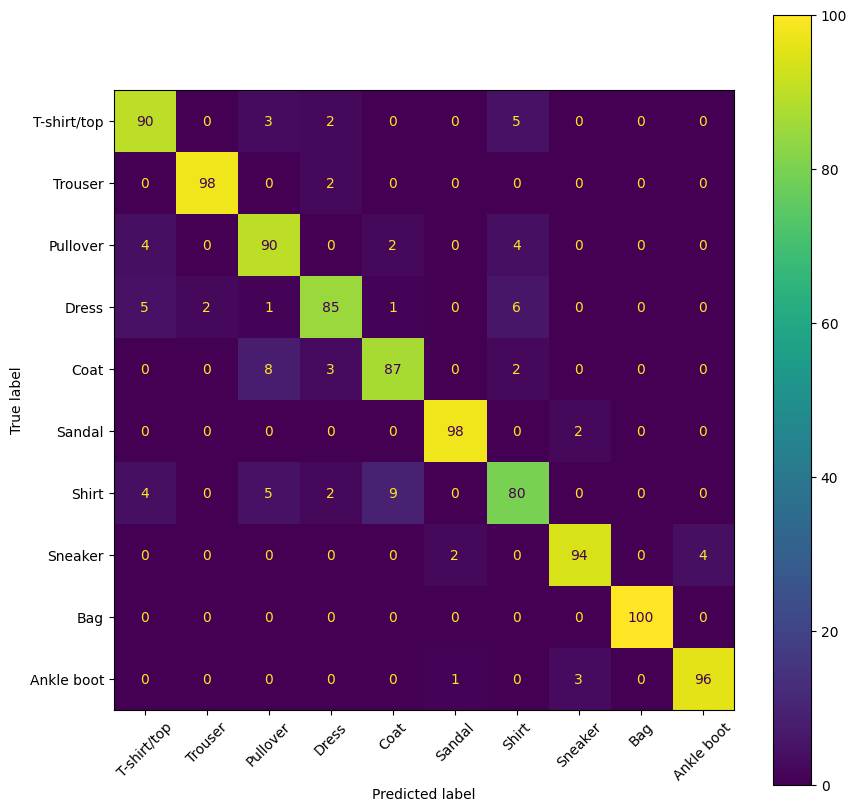

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


outputs = trainer.predict(subset_test_dataset)
print(outputs)

y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

labels = list(classes)
matrix = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
_, ax = plt.subplots(figsize=(10, 10))
display.plot(xticks_rotation=45, ax=ax)
plt.show()